In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [153]:
sms_data = pd.read_csv('sms.csv', encoding='latin-1', sep=',' , usecols=[0,1])

sms_data.head()


,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [154]:
sms_data.shape

(5572, 2)

In [155]:
sms_data.isnull().sum()

Label      0
Message    0
dtype: int64

In [156]:
sms_data.duplicated().sum()

403

In [157]:
sms_data.drop_duplicates(inplace=True)
sms_data.reset_index(drop=True, inplace=True)
sms_data.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [158]:
sms_data.duplicated().sum()

0

In [159]:
sms_data.shape

(5169, 2)

In [160]:
sms_data['Label'].value_counts()

Label
ham     4516
spam     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2a187835f90>,
 [Text(0.5038421623606261, -0.977825687649782, 'ham'),
  Text(-0.5038422539112726, 0.9778256404766694, 'spam')],
 [Text(0.2748229976512505, -0.5333594659907901, '87.4%'),
  Text(-0.27482304758796683, 0.5333594402600015, '12.6%')])

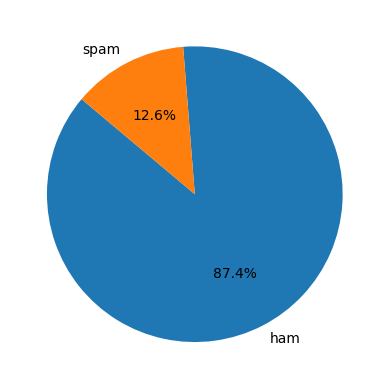

In [162]:
plt.pie(sms_data['Label'].value_counts(), labels=['ham','spam'], autopct='%1.1f%%',startangle=140)


In [163]:
email_data= pd.read_csv('email.csv', encoding='latin-1', sep=',', usecols=[1,2])
email_data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\r\n...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\r\nthis deal is t...


In [164]:
email_data.shape


(5171, 2)

In [165]:
email_data['Label'].value_counts()

Label
ham     3672
spam    1499
Name: count, dtype: int64

In [166]:
email_data.isna().sum()

Label      0
Message    0
dtype: int64

In [167]:
email_data.duplicated().sum()

178

In [168]:
email_data.drop_duplicates(inplace=True)
email_data.reset_index(drop=True, inplace=True)
email_data.duplicated().sum()

0

In [169]:
final_data = pd.concat([email_data , sms_data], axis=0, ignore_index=True)
final_data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\r\n...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\r\nthis deal is t...


In [170]:
final_data.shape

(10162, 2)

In [171]:
final_data.isna().sum()

Label      0
Message    0
dtype: int64

In [172]:
final_data.to_csv('spamham.csv',index=False)

In [173]:
data = pd.read_csv('spamham.csv' ,encoding='latin-1', sep=',')
data.head()

,Label,Message
0,ham,Subject: enron methanol ; meter # : 988291\r\n...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\r\nthis deal is t...


In [174]:
data.shape

(10162, 2)

In [176]:
from collections import Counter
import nltk

count1 = Counter(" ".join(data[data['Label']=='ham']["Message"]).split()).most_common(20)
df1 = pd.DataFrame.from_dict(count1)
df1 = df1.rename(columns={0: "words in non-spam", 1 : "count"})
count2 = Counter(" ".join(data[data['Label']=='spam']["Message"]).split()).most_common(20)
df2 = pd.DataFrame.from_dict(count2)
df2 = df2.rename(columns={0: "words in spam", 1 : "count_"})

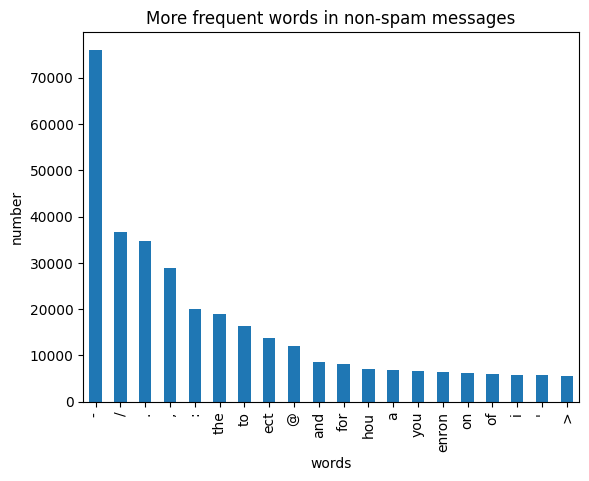

In [177]:
df1.plot.bar(legend = False)
y_pos = np.arange(len(df1["words in non-spam"]))
plt.xticks(y_pos, df1["words in non-spam"])
plt.title('More frequent words in non-spam messages')
plt.xlabel('words')
plt.ylabel('number')
plt.show()

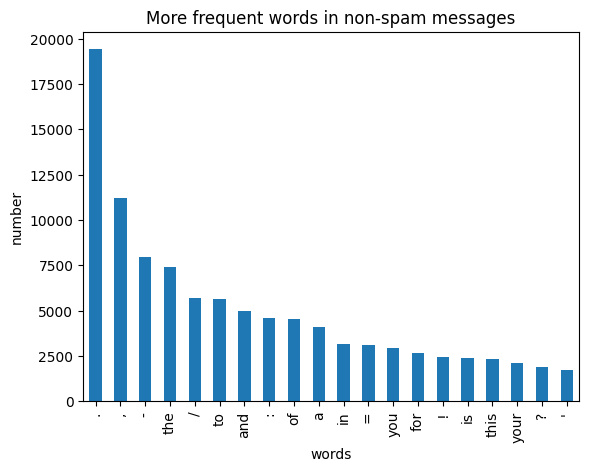

In [178]:
df2.plot.bar(legend = False)
y_pos = np.arange(len(df2["words in spam"]))
plt.xticks(y_pos, df2["words in spam"])
plt.title('More frequent words in non-spam messages')
plt.xlabel('words')
plt.ylabel('number')
plt.show()

In [179]:
from nltk import word_tokenize
from nltk.corpus import stopwords

from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

data['Message'] = data['Message'].str.lower()
#data['Message'] = data['Message'].str.replace(r'\d+','')
data['Message'] = data['Message'].str.replace(r'\w+',' ')
data['Message'] = data['Message'].str.replace(r'\s+',' ')
data['Message'] = data['Message'].str.strip()
data['Message'] = data['Message'].str.replace(r'\b\w\b','')
data['Message'] = data['Message'].str.replace(r'\b\w{1,2}\b','')
data['Message'] = data['Message'].str.replace(r'\s+','')




In [180]:

data.head()

,Label,Message
0,ham,subject: enron methanol ; meter # : 988291\r\n...
1,ham,"subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"subject: photoshop , windows , office . cheap ..."
4,ham,subject: re : indian springs\r\nthis deal is t...


In [181]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\himan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\himan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [182]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [183]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))


def stemming(message):
    message = message.split()
    message = [ps.stem(word) for word in message if word.lower() not in stop_words]
    return ' '.join(message)

In [184]:
example = 'This is a test message'
print(stemming(example))

test messag


In [185]:
from nltk.stem import WordNetLemmatizer

In [186]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\himan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\himan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [187]:
lemmatizer = nltk.stem.WordNetLemmatizer()
def limmatizing(message):
    #message = message.lower()
    message = message.split()
    message = [lemmatizer.lemmatize(word) for word in message if word not in stop_words]
    return ' '.join(message)

In [188]:
example = 'This is a test message'
print(lemmatizing(example))

test message


In [189]:
data['Message'] = data['Message'].apply(lemmatizing)
data.head()

,Label,Message
0,ham,subject: enron methanol ; meter # : 988291 fol...
1,ham,"subject: hpl nom january 9 , 2001 ( see attach..."
2,ham,"subject: neon retreat ho ho ho , ' around wond..."
3,spam,"subject: photoshop , window , office . cheap ...."
4,ham,subject: : indian spring deal book teco pvr re...


In [190]:
# data['Tokenized'] = data['Message'].apply(word_tokenize)
# data.head()

print(data['Message'][0].split()) #word_tokenize is used to split the sentence into words, itnis a part of nltk libarary

['subject:', 'enron', 'methanol', ';', 'meter', '#', ':', '988291', 'follow', 'note', 'gave', 'monday', ',', '4', '/', '3', '/', '00', '{', 'preliminary', 'flow', 'data', 'provided', 'daren', '}', '.', 'please', 'override', 'pop', "'", 'daily', 'volume', '{', 'presently', 'zero', '}', 'reflect', 'daily', 'activity', 'obtain', 'gas', 'control', '.', 'change', 'needed', 'asap', 'economics', 'purpose', '.']


In [191]:
example.split()

['This', 'is', 'a', 'test', 'message']

In [195]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(lowercase=True)

x = cv.fit_transform(data['Message'])
y = data['Label'].values



In [196]:
print(x)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 391909 stored elements and shape (10162, 51949)>
  Coords	Values
  (0, 44741)	1
  (0, 19385)	1
  (0, 31950)	1
  (0, 31944)	1
  (0, 5317)	1
  (0, 21509)	1
  (0, 34232)	1
  (0, 22450)	1
  (0, 32652)	1
  (0, 0)	1
  (0, 37785)	1
  (0, 21399)	1
  (0, 15970)	1
  (0, 38313)	1
  (0, 15909)	1
  (0, 37111)	1
  (0, 35552)	1
  (0, 37405)	1
  (0, 15810)	2
  (0, 49226)	1
  (0, 37849)	1
  (0, 51674)	1
  (0, 39753)	1
  (0, 5847)	1
  (0, 34590)	1
  :	:
  (10158, 23129)	1
  (10158, 24980)	1
  (10158, 21771)	1
  (10158, 19809)	1
  (10159, 32748)	1
  (10159, 36955)	1
  (10159, 43460)	1
  (10159, 46088)	1
  (10159, 7391)	1
  (10159, 44858)	1
  (10160, 22450)	1
  (10160, 49786)	1
  (10160, 29858)	1
  (10160, 21846)	1
  (10160, 33801)	1
  (10160, 23787)	1
  (10160, 11445)	1
  (10160, 43598)	1
  (10160, 26781)	1
  (10160, 19027)	1
  (10160, 5828)	1
  (10160, 9981)	1
  (10161, 33370)	1
  (10161, 47289)	1
  (10161, 40894)	1


In [197]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y = le.fit_transform(y)
y

array([0, 0, 0, ..., 0, 0, 0])

In [198]:
type(y)

numpy.ndarray

In [199]:
pd.Series(y)

0        0
1        0
2        0
3        1
4        0
        ..
10157    1
10158    0
10159    0
10160    0
10161    0
Length: 10162, dtype: int32

In [200]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X , y, test_size=0.3, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((7113, 51940), (3049, 51940), (7113,), (3049,))

In [205]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = MultinomialNB() #using Naive Bayes algorithm for classification
model.fit(x_train, y_train) #fitting model of the training data
y_pred = model.predict(x_test) # predicting the labels on testing data

print("Accuracy: ", accuracy_score(y_test, y_pred)) # checking the accuracy of the model
print("Classification Report: \n", classification_report(y_test, y_pred)) #checking the classification report of the model
#print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy:  0.9491636602164644
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      2404
           1       0.84      0.94      0.89       645

    accuracy                           0.95      3049
   macro avg       0.91      0.95      0.93      3049
weighted avg       0.95      0.95      0.95      3049

